# Project 2: Scene Reconstruction

## Timeline: 06/01/2026 10:00 AM - 06/22/2026 10:00 AM
## DUE-BY: 22.06.2026, 10:00 AM

This project addresses scene reconstruction.
You will use data from the public dataset [2014 Stereo Dataset](https://vision.middlebury.edu/stereo/data/scenes2014/), which contains stereo images of different objects.
You will estimate disparity and depth maps from the images, apply graphical models to smooth the results, and perform surface extraction of the 3D scene.

**Group Rules:**
Solo submissions will not be graded, please form groups of ideally three members with at least two. Each group member will need to mark their contributions to the code and this person will be responsible to answer questions. Make sure to register on time for the group presentations, registration will be possible until the submission deadline.

Submit your group's results through ILIAS and make sure all group members are registered. Please only upload your code and notebooks, **do not** upload the image data with your submission.


In [1]:
import cv2
from PIL import Image
from tqdm.auto import tqdm 
try:
    import gco
except:
    pass
import numpy as np
import matplotlib.pyplot as plt
from functions_student import *
%matplotlib inline


## Exercise 1 (by Ahmed)

**Learning goals:** F-matrix estimation & Rectification

The goal of this exercise is to implement the F-matrix estimation to rectify two stereo images.

1. Load the provided stereo images (`data/img0.jpg` and `data/img1.jpg`). *Note: You are welcome to use your own camera photos to test your implementation, but your final code must work on the provided data.*
2. Use what you learned about feature descriptors and key point matching to find correspondences between the two images. Plot the detected points and matches. 
3. Use identified matches to estimate the fundamental matrix (F-matrix). You may use existing implementations for key point detection and matching, but you should implement the matrix estimation yourself.
4. Apply the estimated F-matrix to rectify the images.


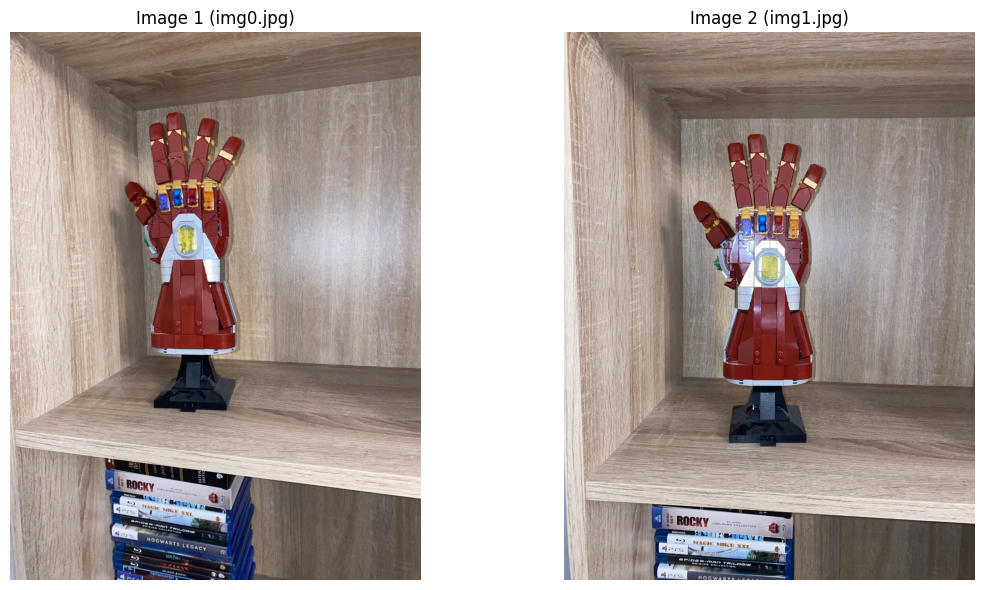

In [2]:
# Load images for Exercise 1
img1_ex1 = cv2.imread('data/img0.jpg')
img2_ex1 = cv2.imread('data/img1.jpg')

# Convert to RGB for display
img1_ex1_rgb = cv2.cvtColor(img1_ex1, cv2.COLOR_BGR2RGB)
img2_ex1_rgb = cv2.cvtColor(img2_ex1, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img1_ex1_rgb)
axes[0].set_title('Image 1 (img0.jpg)')
axes[0].axis('off')
axes[1].imshow(img2_ex1_rgb)
axes[1].set_title('Image 2 (img1.jpg)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


Found 1690 raw matches, 682 after RANSAC filtering.


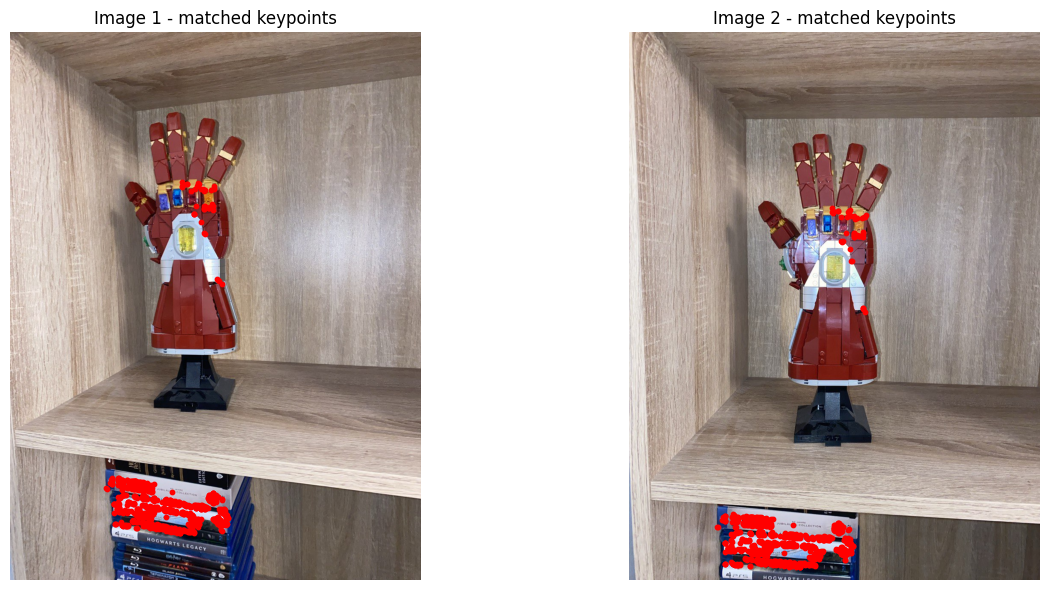

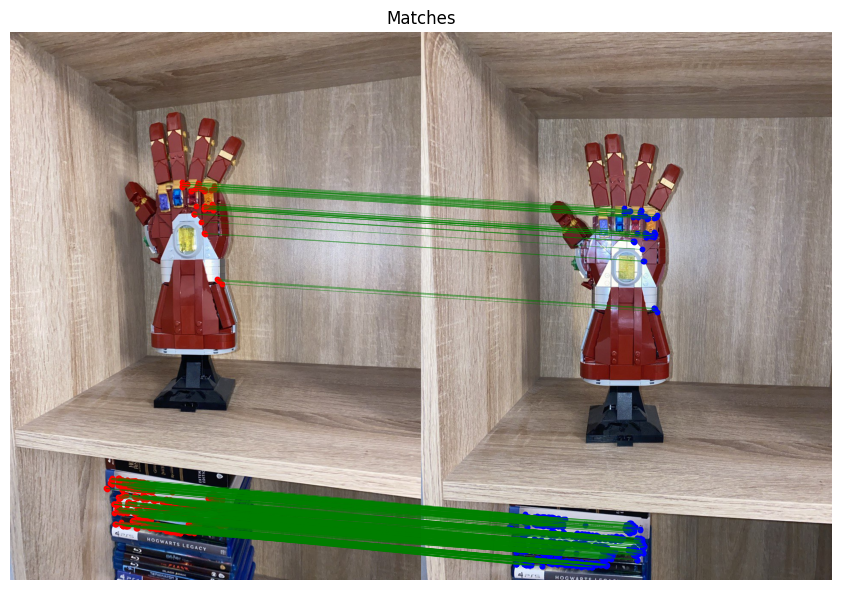

In [3]:
# TODO: Find correspondences between img1_ex1 and img2_ex1
# 1. Extract keypoints and descriptors
gray1 = cv2.cvtColor(img1_ex1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_ex1, cv2.COLOR_BGR2GRAY)


kp1, desc1 = get_keypoints(gray1)
kp2, desc2 = get_keypoints(gray2)

# 2. Match descriptors
matches = matching(desc1, desc2, max_ratio=1.0, cross_checking=True)

points1 = kp1[matches[:, 0]]
points2 = kp2[matches[:, 1]]

# 3. Filter matches using RANSAC (e.g. cv2.findHomography)
# We use findHomography to get an initial inlier mask; this removes gross outliers.
H, mask = cv2.findHomography(points1, points2, cv2.RANSAC, ransacReprojThreshold=3.0)
mask = mask.ravel().astype(bool)


# IMPORTANT: Store your final matched keypoints in `keypoints1_match` and `keypoints2_match`
keypoints1_match = points1[mask]
keypoints2_match = points2[mask]

print(f"Found {len(points1)} raw matches, {len(keypoints1_match)} after RANSAC filtering.")

# 4. Plot the matching result
show_matching_result(img1_ex1, img2_ex1, keypoints1_match, keypoints2_match)


In [4]:
# TODO: Estimate the F-matrix manually using SVD and normalization
# IMPORTANT: Store the result in a variable named `F`
F = compute_fundamental_matrix_normalized(keypoints1_match, keypoints2_match)

print("Estimated Fundamental Matrix F:")
print(F)

# Optional sanity check: epipolar constraint on inliers
pts1_h = np.hstack((keypoints1_match, np.ones((keypoints1_match.shape[0], 1))))
pts2_h = np.hstack((keypoints2_match, np.ones((keypoints2_match.shape[0], 1))))
errors = np.abs(np.sum(pts2_h * (F @ pts1_h.T).T, axis=1))
print(f"Mean epipolar constraint error: {errors.mean():.6f}")
print(f"Max epipolar constraint error: {errors.max():.6f}")


Estimated Fundamental Matrix F:
[[-3.42780492e-06  7.47092601e-06 -1.93571981e-02]
 [-3.80953518e-07  1.78291628e-07  3.33781160e-02]
 [ 1.87046767e-02 -3.88469650e-02  1.00000000e+00]]
Mean epipolar constraint error: 0.023851
Max epipolar constraint error: 0.116088


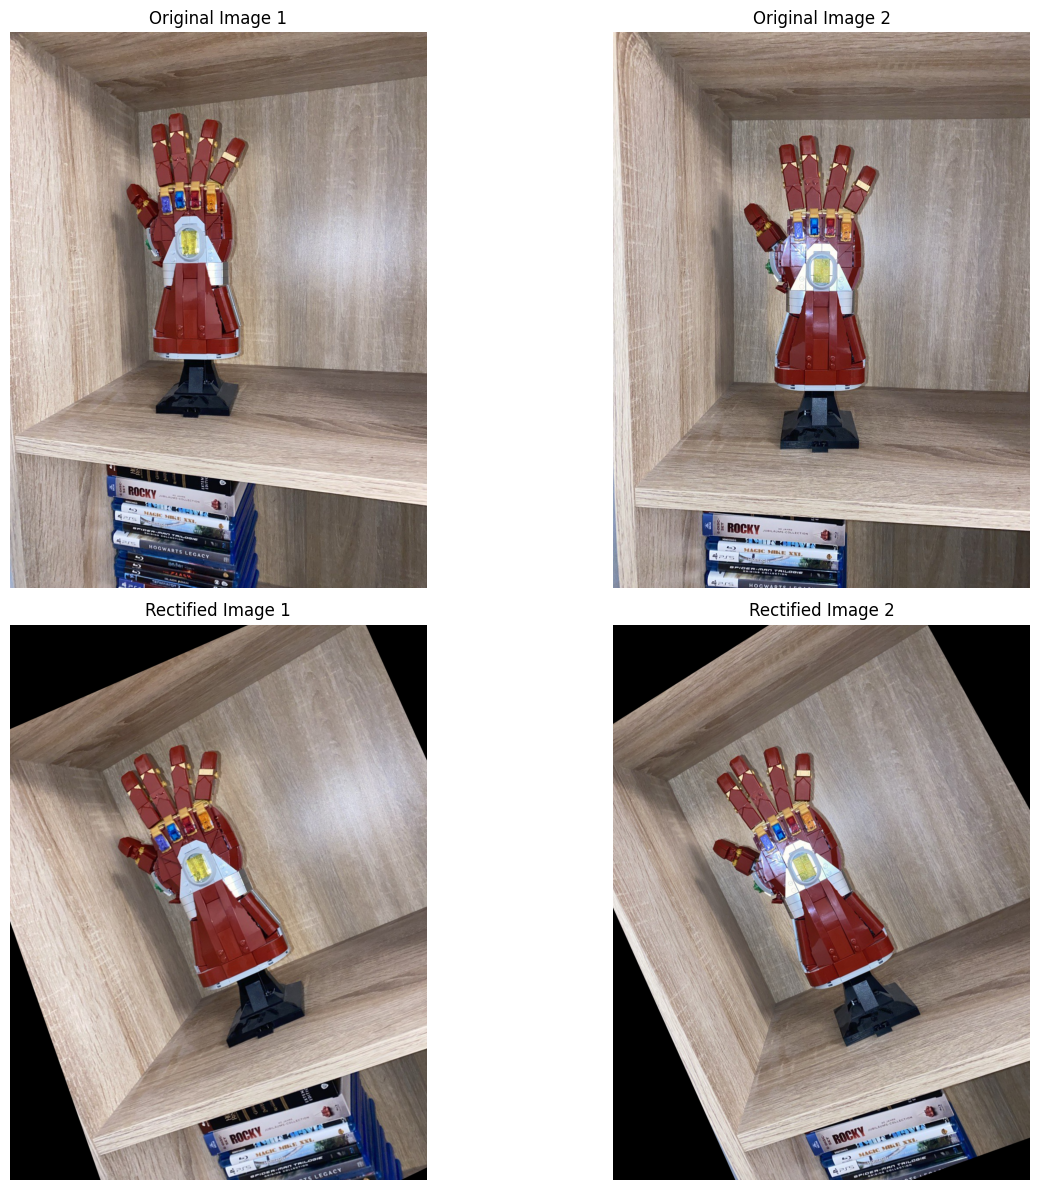

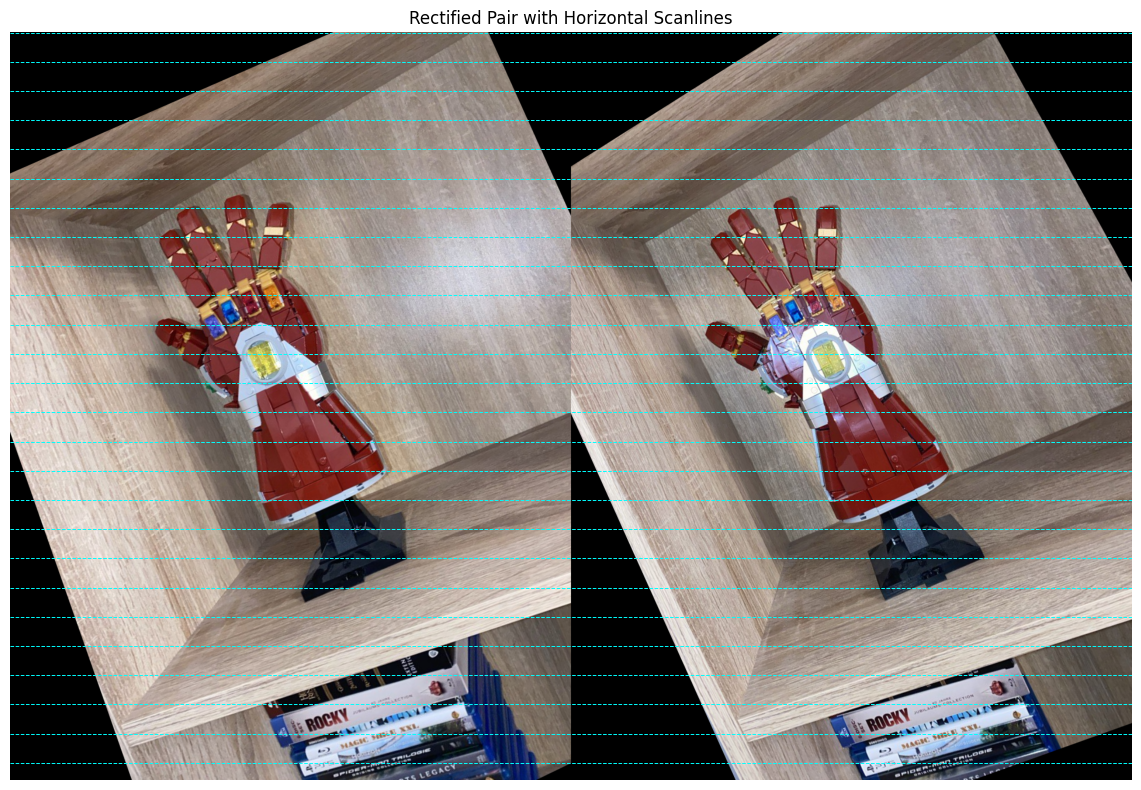

In [5]:
# TODO: Rectify the images using the estimated F-matrix
# 1. Compute rectification homographies using cv2.stereoRectifyUncalibrated
#    (Store them in variables H1 and H2)
# 2. Apply the homographies using cv2.warpPerspective
#    (Store the warped images in img1_rectified_ex1 and img2_rectified_ex1)

h, w = img1_ex1.shape[:2]

success, H1, H2 = cv2.stereoRectifyUncalibrated(
    keypoints1_match,
    keypoints2_match,
    F,
    imgSize=(w, h),
    threshold=5.0
)

if not success:
    raise RuntimeError("stereoRectifyUncalibrated failed. Try more/better matches or check F.")

# 2. Apply the homographies using cv2.warpPerspective
img1_rectified_ex1 = cv2.warpPerspective(img1_ex1, H1, (w, h))
img2_rectified_ex1 = cv2.warpPerspective(img2_ex1, H2, (w, h))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0, 0].imshow(cv2.cvtColor(img1_ex1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image 1')
axes[0, 0].axis('off')
axes[0, 1].imshow(cv2.cvtColor(img2_ex1, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Original Image 2')
axes[0, 1].axis('off')
axes[1, 0].imshow(cv2.cvtColor(img1_rectified_ex1, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Rectified Image 1')
axes[1, 0].axis('off')
axes[1, 1].imshow(cv2.cvtColor(img2_rectified_ex1, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Rectified Image 2')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

# Overlay with horizontal scanlines to verify rectification
overlay = np.hstack((img1_rectified_ex1, img2_rectified_ex1))
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(overlay_rgb)
for y in range(0, overlay.shape[0], 50):
    ax.axhline(y=y, color='cyan', linestyle='--', linewidth=0.7)
ax.set_title('Rectified Pair with Horizontal Scanlines')
ax.axis('off')
plt.tight_layout()
plt.show()

## Exercise 2 (By Ammara Ansari)

**Learning goals:** Compute scene depth using block matching

After rectifying images in the last exercise, the goal of this exercise will be to compute the scene depth. We will use a different pair of images for this task, located in `Sword1-perfect/`.

1. Compute the disparity using the methods described in the lecture.
   *Hint: We recommend using Sum of Absolute Differences (SAD) with a window size of 7x7 and the dynamically estimated maximum disparity.*
2. Implement Left-Right cross-checking to resolve ambiguous matches.
3. Use the computed disparity to estimate and display the depth.

**Tip:** If your implementation is too slow, you may downscale images to speed up computation.
**Note:** Please implement these algorithms yourself in `functions.py` or use the provided skeleton.


In [6]:

# Load images for Exercise 2 (Sword1-perfect)
img1_orig = np.array(Image.open('Sword1-perfect/im0.png').convert('RGB'))
img2_orig = np.array(Image.open('Sword1-perfect/im1.png').convert('RGB'))


In [7]:
# TODO: Estimate maximum disparity using keypoints
# 1. Extract keypoints and match them between img1_orig and img2_orig

kp1, desc1 = get_keypoints(cv2.cvtColor(img1_orig, cv2.COLOR_RGB2GRAY))
kp2, desc2 = get_keypoints(cv2.cvtColor(img2_orig, cv2.COLOR_RGB2GRAY))
matches = matching(desc1, desc2, max_ratio=0.7, cross_checking=True)

points1 = kp1[matches[:, 0]]
points2 = kp2[matches[:, 1]]
# 2. Compute the max expected disparity from the matches
# 3. Scale down the max_disparity by 0.25 (since we will downscale the images by 0.25)
# IMPORTANT: Store the final scaled value in `max_disparity`
max_disparity_full = get_max_expected_disparity(points1, points2)
max_disparity = int(np.ceil(max_disparity_full * 0.25))

print(f"Full-resolution maximum expected disparity: {max_disparity_full}")
print(f"Downscaled (0.25) bounded disparity search range: {max_disparity}")

Full-resolution maximum expected disparity: 190
Downscaled (0.25) bounded disparity search range: 48


In [8]:
# Prepare images for block matching
img1 = cv2.cvtColor(img1_orig, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
img2 = cv2.cvtColor(img2_orig, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# Downscale to speed up computation
img1 = cv2.resize(img1, (0,0), fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (0,0), fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)


In [9]:
window_size = 7
# TODO: Compute disparity maps for L->R and R->L directions
# IMPORTANT: Store results in `disparity_L` and `disparity_R`
print("Computing Left-to-Right disparity map...")
disparity_L = compute_disparity_map(
    img1, img2, window_size=window_size, max_disparity=max_disparity, direction="L->R"
)

print("Computing Right-to-Left disparity map...")
disparity_R = compute_disparity_map(
    img2, img1, window_size=window_size, max_disparity=max_disparity, direction="R->L"
)

Computing Left-to-Right disparity map...
Computing Right-to-Left disparity map...


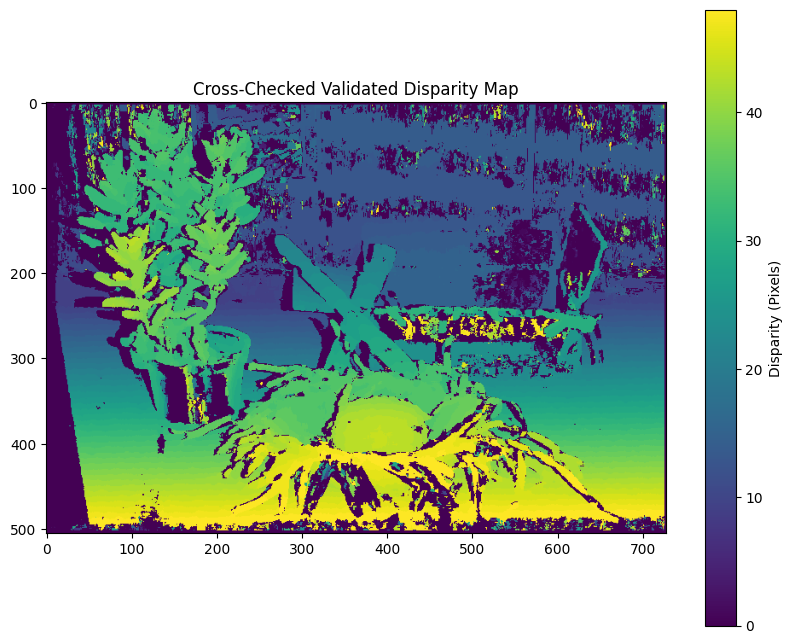

In [10]:
# TODO: Perform cross-checking to resolve ambiguous matches
# IMPORTANT: Store result in `disparity_map`
disparity_map = cross_check_disparities(disparity_L, disparity_R, threshold=1.0)

# --- Visualization ---

if disparity_map is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(disparity_map, cmap='viridis')
    plt.colorbar(label='Disparity (Pixels)')
    plt.title('Cross-Checked Validated Disparity Map')
    plt.show()


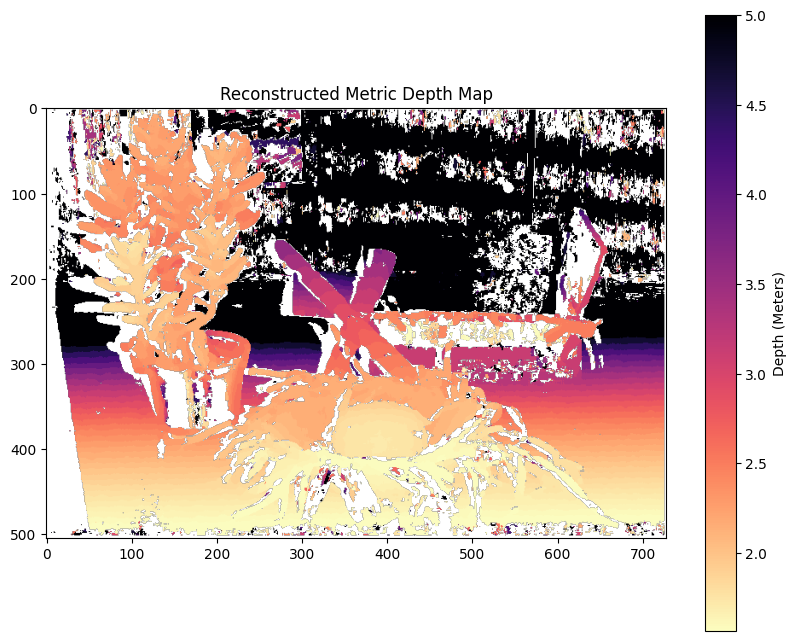

In [11]:
focal_length_pixels = 1718.2185 * 0.25  
baseline_meters = 0.174724
# TODO: Estimate depth from disparity
# IMPORTANT: Store result in `depth_map`
depth_map = estimate_depth(disparity_map, focal_length_pixels, baseline_meters)

# --- Visualization ---
if depth_map is not None:
    visual_depth = np.copy(depth_map)
    visual_depth[depth_map == 0] = np.nan
    
    plt.figure(figsize=(10, 8))
    plt.imshow(visual_depth, cmap='magma_r', vmax=5) 
    plt.colorbar(label='Depth (Meters)')
    plt.title('Reconstructed Metric Depth Map')
    plt.show()

## Exercise 3 (BY Natalia)

**Learning goals:** Smooth depth maps using an MRF

To improve the quality of the depth estimation, you will now apply a Markov Random Field (MRF) to smooth the disparity maps.

1. Install `gco-wrapper`. If you are on Windows, ensure you have a C++ compiler installed. 
2. Convert the task of smoothing the disparity map into a MRF problem. 
   *Hint: For the MRF, consider defining your unary potentials as the absolute difference between the proposed label and the initial computed disparity. For pairwise potentials, a simple Potts model (penalizing adjacent pixels that have different disparity labels) works well.*
3. Recompute the depth map using your corrected disparity maps and compare them to the previous result.


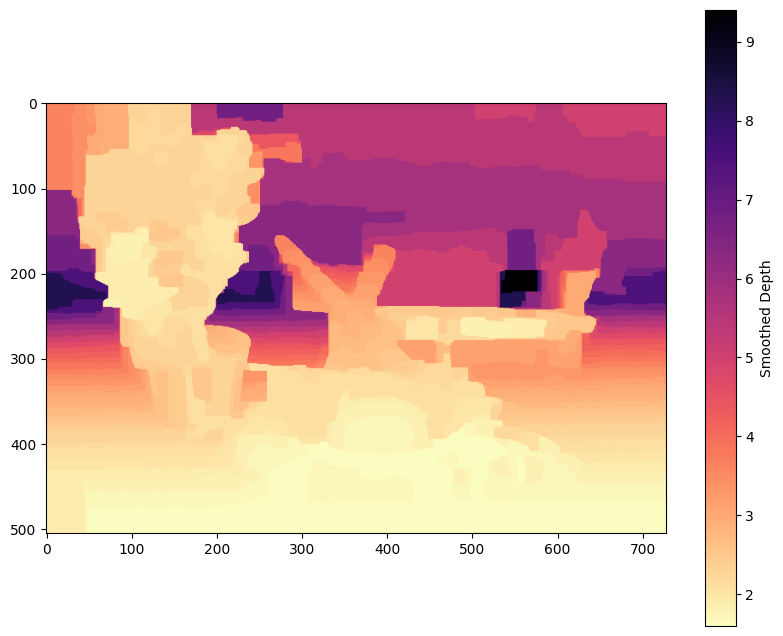

In [12]:
# TODO: Smooth the depth map using an MRF
# IMPORTANT: Store result in `smoothed_depth_map`
smoothed_depth_map = apply_mrf(depth_map, max_disparity)

# --- Visualization ---
if smoothed_depth_map is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(smoothed_depth_map, cmap='magma_r')
    plt.colorbar(label='Smoothed Depth')
    plt.show()


## Exercise 4 (Optional)

**Learning goals:** Scene surface construction (Marching Squares)

In this final exercise, you will apply surface extraction to create scene surfaces from the estimated depth map.

1. Implement the marching squares algorithm to extract isosurfaces from the depth maps.
   *Hint: Remember to handle the ambiguous saddle cases (where opposite corners share the same sign) by subsampling the center of the cell (averaging the 4 corners) as discussed in the lecture.*
2. Apply your algorithm to your previously created depth maps.
3. Plot the computed surfaces on top of the original images.

# Note: this exercise is ahead of the lecture and therefore optional.  


In [13]:
#check the min and max to help select the isovalues
print("min:", np.min(smoothed_depth_map))
print("max:", np.max(smoothed_depth_map))
print("mean:", np.mean(smoothed_depth_map))

min: 1.6
max: 9.4
mean: 3.5618855402023715


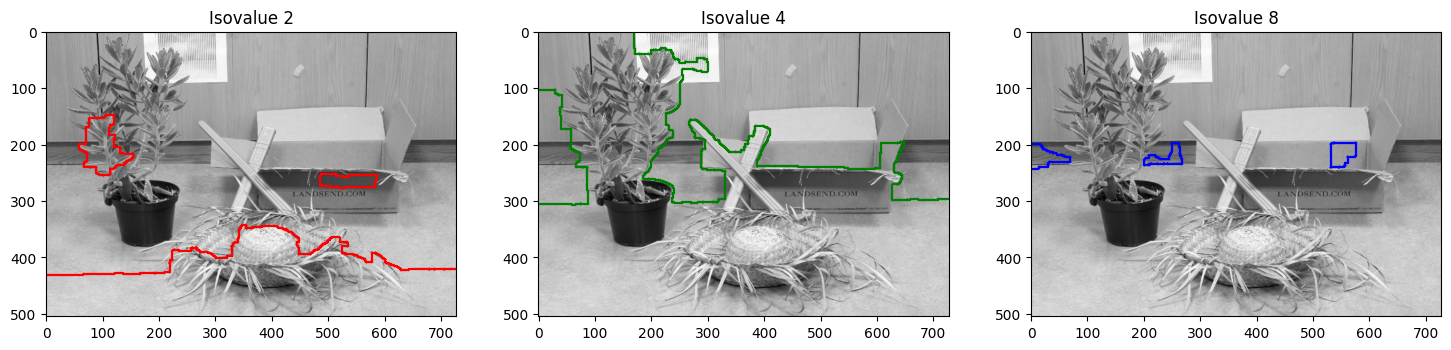

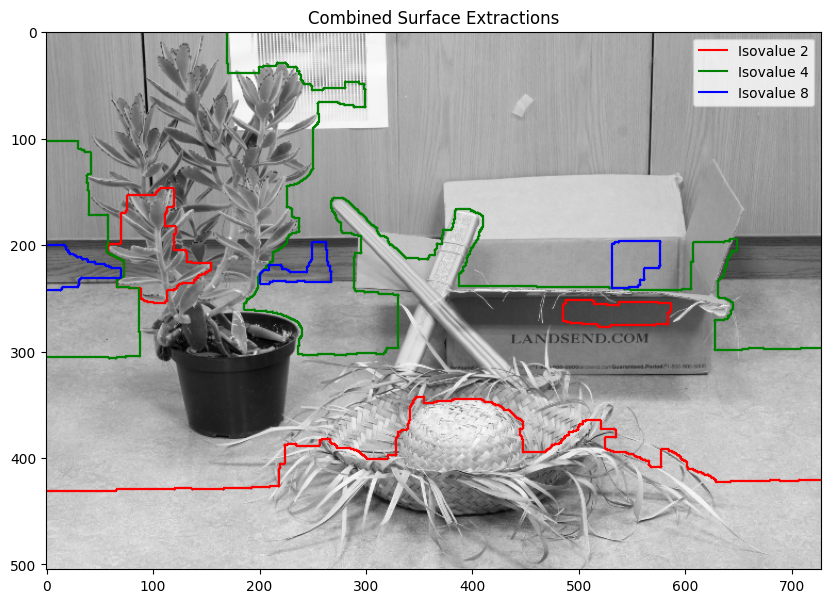

In [15]:
isovalues = [2, 4, 8] # you may adjust these values to experiment
colors = ['red', 'green', 'blue']

# Individual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, iso in enumerate(isovalues):
    segments = extract_surface_marching_squares(smoothed_depth_map, isovalue=iso)
    axes[i].imshow(img1, cmap='gray')
    axes[i].set_title(f'Isovalue {iso}')
    for pt1, pt2 in segments:
        axes[i].plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color=colors[i])
plt.show()

# Combined plot
plt.figure(figsize=(10, 8))
plt.imshow(img1, cmap='gray')
plt.title('Combined Surface Extractions')
for i, iso in enumerate(isovalues):
    segments = extract_surface_marching_squares(smoothed_depth_map, isovalue=iso)
    for pt1, pt2 in segments:
        plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color=colors[i], label=f'Isovalue {iso}' if pt1 == segments[0][0] else '')
plt.legend()
plt.show()
